# Chronos-2 Custom Pipeline on FEV Data

This notebook tests the full integration path:

1. load an FEV dataset from Hugging Face with the local `fev_loader`
2. convert it into the long dataframe format expected by Chronos
3. run `CustomChronosPipeline.predict_df()` on that dataframe
4. optionally compare the result with the original `Chronos2Pipeline`
5. inspect stored attention tensors from the custom pipeline

It is the notebook version of the new script-based workflow, but with more visibility into each step.

## 1. Install dependencies

This notebook needs the Chronos package, plotting libraries, and the Hugging Face dataset stack used by the FEV loader.

In [5]:
# Run once, then restart the kernel if needed.
%pip install -q chronos-forecasting pandas torch matplotlib datasets pyarrow


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Add repo root to `sys.path`

We import the local `chronos_custom` package directly from the repo so the notebook always uses the current working copy.

In [6]:
import sys
from pathlib import Path

# Walk upward until we find the local package folder.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "chronos_custom").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        print(f"Repo root added to sys.path: {candidate}")
        break
else:
    raise RuntimeError("chronos_custom/ not found. Run this notebook from inside the repo.")

Repo root added to sys.path: /Users/ruoccoma/Documents/Playground/chronos-custom


## 3. Imports

We import both Chronos pipelines and the FEV loader helpers so the notebook can show each stage explicitly.

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
from chronos import Chronos2Pipeline

from chronos_custom import (
    CustomChronosPipeline,
    compute_group_ids,
    infer_fev_target_columns,
    load_fev_long_dataframe,
)

/Users/ruoccoma/Documents/Playground/chronos-custom/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4. Notebook settings

Pick a small configuration and prediction length first.

This notebook now defaults to a multiseries FEV config so the custom `group_ids` logic has a meaningful chance to affect cross-series attention.

In [26]:
MODEL_ID = "amazon/chronos-2"
FEV_CONFIG = "LOOP_SEATTLE_1H"
FEV_SPLIT = "train"
MAX_SERIES = 10
PREDICTION_LENGTH = 48
TARGETS = None
PLOT_TARGET = None
CROSS_LEARNING = False
RUN_BASELINE = True

# `LOOP_SEATTLE_1H` is a good default for grouping experiments because the dataset
# contains many distinct series ids rather than a single aggregated series.
print(f"Model: {MODEL_ID}")
print(f"FEV config: {FEV_CONFIG}")
print(f"Split: {FEV_SPLIT}")
print(f"Max series: {MAX_SERIES}")
print(f"Prediction length: {PREDICTION_LENGTH}")

Model: amazon/chronos-2
FEV config: LOOP_SEATTLE_1H
Split: train
Max series: 10
Prediction length: 48


## 5. Load FEV data with the local loader

The loader downloads the selected FEV config and converts the row-per-series layout into one long dataframe with columns such as `id`, `timestamp`, `target`, and any covariates.

In [27]:
# Pull one FEV config from Hugging Face and immediately convert it to long format.
context_df, value_columns = load_fev_long_dataframe(
    FEV_CONFIG,
    split=FEV_SPLIT,
    max_series=MAX_SERIES,
)
# If the caller did not choose targets explicitly, infer them from the loaded columns.
target_columns = list(TARGETS) if TARGETS is not None else infer_fev_target_columns(value_columns)
plot_target = PLOT_TARGET or target_columns[0]
series_ids = context_df["id"].unique().tolist()

print("Loaded dataframe shape:", context_df.shape)
print("Value columns:", value_columns)
print("Target columns:", target_columns)
print("Unique series:", len(series_ids))
print("Plot target:", plot_target)

context_df.head()

Loaded dataframe shape: (87600, 3)
Value columns: ['target']
Target columns: ['target']
Unique series: 10
Plot target: target


,id,timestamp,target
0,0,2015-01-01 00:00:00,62.189457
1,0,2015-01-01 01:00:00,62.927940
2,0,2015-01-01 02:00:00,63.341717
3,0,2015-01-01 03:00:00,63.144405
4,0,2015-01-01 04:00:00,63.002350


## 6. Quick dataset checks

These checks are useful before loading the model because they confirm the dataframe has the structure that `predict_df()` expects.

In [28]:
# Confirm the core columns exist and timestamps are ready for Chronos.
assert "id" in context_df.columns
assert "timestamp" in context_df.columns
assert set(target_columns).issubset(context_df.columns)
assert pd.api.types.is_datetime64_any_dtype(context_df["timestamp"])

# Count rows per series to understand whether this config is single-series or multi-series.
series_lengths = context_df.groupby("id").size().sort_values(ascending=False)
display(series_lengths.to_frame(name="rows").head(10))

if len(series_ids) == 1:
    print("Note: this config only has one series id in the loaded sample, so custom group_ids will not change cross-series behavior.")
else:
    print("This sample has multiple series ids, so custom group_ids can affect cross-series attention.")

,rows
id,
0,8760
1,8760
2,8760
3,8760
4,8760
5,8760
6,8760
7,8760
8,8760


This sample has multiple series ids, so custom group_ids can affect cross-series attention.


## 7. Preview the current custom grouping rule

The repo's default `compute_group_ids()` implementation splits the batch into two groups. This preview shows how the current rule behaves for the number of loaded series.

In [29]:
# Preview the group ids that will be assigned by the custom pipeline for this batch size.
preview_group_ids = compute_group_ids(len(series_ids))
preview_df = pd.DataFrame({"id": series_ids, "group_id": preview_group_ids.tolist()})
preview_df.head(MAX_SERIES)

,id,group_id
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
5,5,1
6,6,1
7,7,1
8,8,1
9,9,1


## 8. Load the custom Chronos-2 pipeline

The custom pipeline differs from the original one in two ways:
- it injects repo-defined `group_ids`
- it stores temporal and group attention tensors after prediction

In [30]:
custom_pipeline = CustomChronosPipeline.from_pretrained(MODEL_ID)
custom_pipeline.reset_attentions()
print("Custom pipeline loaded.")

Custom pipeline loaded.


## 9. Run `predict_df()` with the custom pipeline

The long dataframe from the FEV loader is passed directly into `predict_df()`. Any non-target columns are treated as covariates by Chronos.

In [31]:
# Pass a string for univariate targets or a list for multivariate targets.
target_arg = target_columns if len(target_columns) > 1 else target_columns[0]

pred_custom = custom_pipeline.predict_df(
    context_df,
    prediction_length=PREDICTION_LENGTH,
    id_column="id",
    timestamp_column="timestamp",
    target=target_arg,
)

print("Custom prediction shape:", pred_custom.shape)
pred_custom.head()

/Users/ruoccoma/Documents/Playground/chronos-custom/.venv/lib/python3.14/site-packages/chronos/chronos2/dataset.py:89: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  task_target = torch.from_numpy(task_target)


Using group_ids:
tensor([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])
Custom prediction shape: (480, 13)


,id,timestamp,target_name,predictions,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0,0,2016-01-01 00:00:00,target,63.572960,63.029137,63.218143,63.370880,63.477585,63.572960,63.629482,63.734715,63.853699,64.098618
1,0,2016-01-01 01:00:00,target,63.127438,62.378822,62.708435,62.888062,63.012566,63.127438,63.239613,63.382202,63.594959,63.936222
2,0,2016-01-01 02:00:00,target,62.196148,61.171631,61.562428,61.807583,62.006104,62.196148,62.390869,62.594563,62.891682,63.335888
3,0,2016-01-01 03:00:00,target,61.435200,60.070183,60.606693,60.914005,61.181137,61.435200,61.683453,61.965954,62.361828,62.957970
4,0,2016-01-01 04:00:00,target,60.157887,58.134895,58.925171,59.408043,59.791420,60.157887,60.543575,60.968655,61.523361,62.310741


## 10. Optional baseline: original Chronos-2 pipeline

This baseline helps check whether the custom pipeline is wired correctly. The difference is that the original pipeline only supports binary cross-learning control through `cross_learning`.

In [32]:
pred_original = None

if RUN_BASELINE:
    original_pipeline = Chronos2Pipeline.from_pretrained(MODEL_ID)
    pred_original = original_pipeline.predict_df(
        context_df,
        prediction_length=PREDICTION_LENGTH,
        id_column="id",
        timestamp_column="timestamp",
        target=target_arg,
        cross_learning=CROSS_LEARNING,
    )
    print("Original prediction shape:", pred_original.shape)
    display(pred_original.head())
else:
    print("Baseline run skipped.")

Original prediction shape: (480, 13)


,id,timestamp,target_name,predictions,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
0,0,2016-01-01 00:00:00,target,63.632816,63.062656,63.277016,63.438248,63.543148,63.632816,63.681347,63.777790,63.890030,64.123787
1,0,2016-01-01 01:00:00,target,63.195354,62.414799,62.775253,62.965771,63.088238,63.195354,63.293407,63.418930,63.617737,63.946918
2,0,2016-01-01 02:00:00,target,62.194653,61.119476,61.546013,61.804619,62.006073,62.194653,62.380737,62.573952,62.861362,63.297047
3,0,2016-01-01 03:00:00,target,61.420559,59.926308,60.537773,60.882568,61.162960,61.420559,61.666294,61.945843,62.339825,62.931210
4,0,2016-01-01 04:00:00,target,60.172653,57.968983,58.845985,59.376686,59.787567,60.172653,60.568085,61.009464,61.583031,62.366226


## 11. Inspect captured attention tensors

Because the custom pipeline calls the model with `output_attentions=True`, the prediction step stores attention weights that can be inspected after the forecast completes.

In [33]:
# The outer list is one entry per autoregressive step.
# Each inner tuple contains one tensor per encoder layer.
print("Autoregressive steps with temporal attention:", len(custom_pipeline.time_attentions))
print("Autoregressive steps with group attention:", len(custom_pipeline.group_attentions))

if custom_pipeline.time_attentions:
    print("Temporal attention layers in first step:", len(custom_pipeline.time_attentions[0]))
    print("Temporal attention tensor shape:", tuple(custom_pipeline.time_attentions[0][0].shape))

if custom_pipeline.group_attentions:
    print("Group attention layers in first step:", len(custom_pipeline.group_attentions[0]))
    print("Group attention tensor shape:", tuple(custom_pipeline.group_attentions[0][0].shape))

Autoregressive steps with temporal attention: 1
Autoregressive steps with group attention: 1
Temporal attention layers in first step: 12
Temporal attention tensor shape: (10, 12, 516, 516)
Group attention layers in first step: 12
Group attention tensor shape: (516, 12, 10, 10)


## 12. Plot one forecast

We overlay the historical context and the forecast for one series and one target. If the baseline was run, we plot both forecasts for a side-by-side comparison.

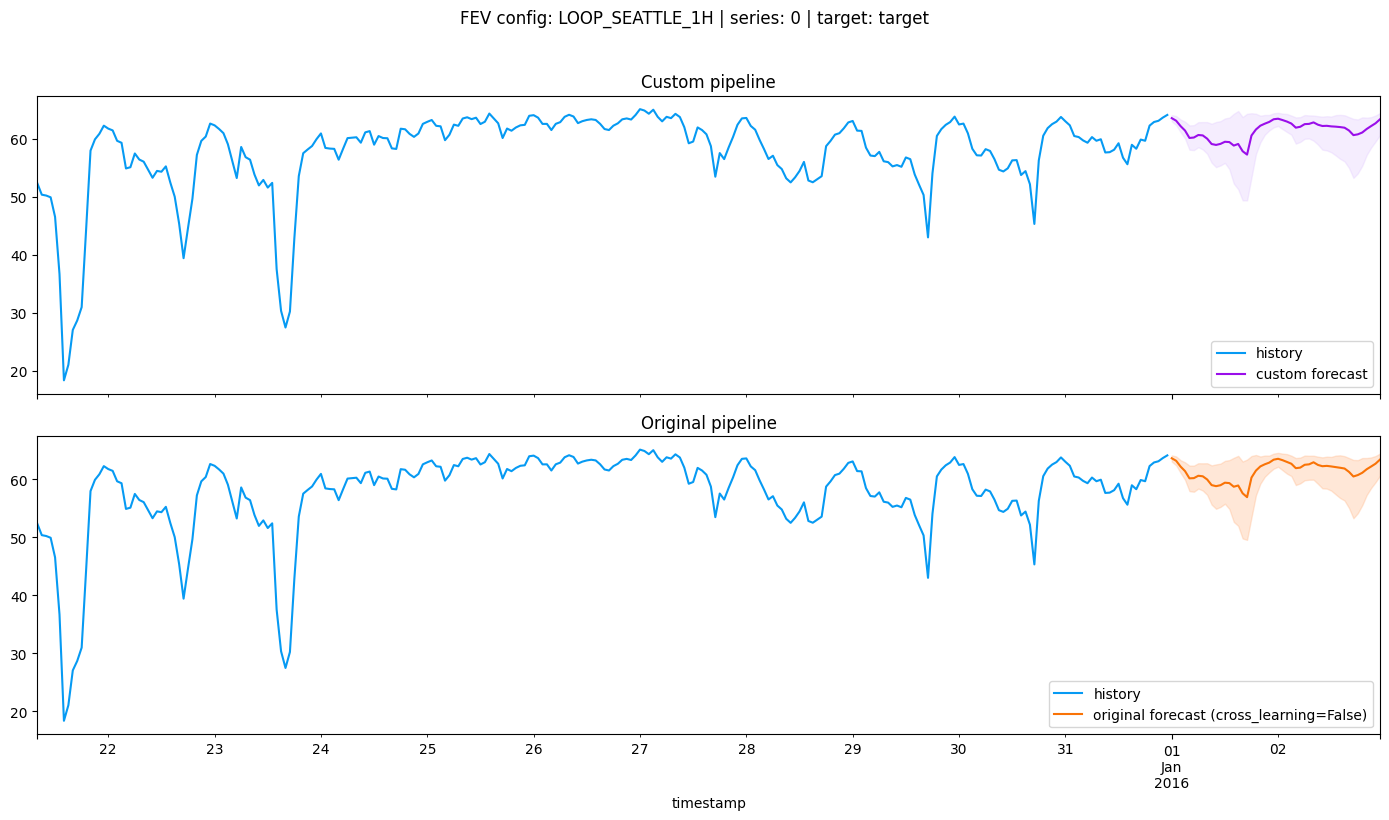

In [34]:
# Choose the first series id in the dataframe as the plotting example.
series_id = series_ids[0]

# Historical context from the loaded FEV dataframe.
ts_context = (
    context_df[context_df["id"] == series_id]
    .sort_values("timestamp")
    .set_index("timestamp")[plot_target]
    .tail(256)
)

# Custom forecast for the selected series/target.
ts_custom = pred_custom[
    (pred_custom["id"] == series_id) & (pred_custom["target_name"] == plot_target)
].set_index("timestamp")

if pred_original is None:
    fig, ax = plt.subplots(figsize=(14, 5))
    ts_context.plot(ax=ax, label="history", color="xkcd:azure")
    ts_custom["predictions"].plot(ax=ax, label="custom forecast", color="xkcd:violet")
    ax.fill_between(ts_custom.index, ts_custom["0.1"], ts_custom["0.9"], alpha=0.3, color="xkcd:light lavender")
    ax.set_title(f"Custom pipeline on {FEV_CONFIG} | {series_id} | {plot_target}")
    ax.legend()
    plt.show()
else:
    ts_original = pred_original[
        (pred_original["id"] == series_id) & (pred_original["target_name"] == plot_target)
    ].set_index("timestamp")

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    ts_context.plot(ax=axes[0], label="history", color="xkcd:azure")
    ts_custom["predictions"].plot(ax=axes[0], label="custom forecast", color="xkcd:violet")
    axes[0].fill_between(ts_custom.index, ts_custom["0.1"], ts_custom["0.9"], alpha=0.3, color="xkcd:light lavender")
    axes[0].set_title("Custom pipeline")
    axes[0].legend()

    ts_context.plot(ax=axes[1], label="history", color="xkcd:azure")
    ts_original["predictions"].plot(ax=axes[1], label=f"original forecast (cross_learning={CROSS_LEARNING})", color="xkcd:orange")
    axes[1].fill_between(ts_original.index, ts_original["0.1"], ts_original["0.9"], alpha=0.3, color="xkcd:peach")
    axes[1].set_title("Original pipeline")
    axes[1].legend()

    plt.suptitle(f"FEV config: {FEV_CONFIG} | series: {series_id} | target: {plot_target}", y=1.02)
    plt.tight_layout()
    plt.show()

## 13. Next step

If this notebook runs successfully, the custom pipeline and the FEV loader are working together correctly.

From here you can:
- swap in a multi-series FEV config to test cross-series grouping more meaningfully
- modify `compute_group_ids()` in `topology.py` and rerun the notebook
- inspect individual attention maps in more detail for one layer and one prediction step